In [1]:
!pip install kaggle ultralytics tensorflow opencv-python matplotlib scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.4 MB/s eta 0:00:00


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models

def unet_model(input_shape=(128, 128, 3), num_classes=1):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Bottleneck
    b1 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    b1 = layers.Conv2D(256, 3, activation='relu', padding='same')(b1)

    # Decoder
    u1 = layers.Conv2DTranspose(128, 2, strides=(2, 2), padding='same')(b1)
    u1 = layers.concatenate([u1, c2])
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(u1)
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(c3)

    u2 = layers.Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(c3)
    u2 = layers.concatenate([u2, c1])
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(u2)
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(c4)

    outputs = layers.Conv2D(num_classes, 1, activation='sigmoid')(c4)

    model = models.Model(inputs, outputs)
    return model

unet = unet_model()
unet.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 64, 64,    │    131,200 │ conv2d_5[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │    295,040 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 128, 128,  │     32,832 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │     73,792 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_8[0][0]  

 Total params: 1,862,849 (7.11 MB)

 Trainable params: 1,862,849 (7.11 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os, cv2, glob
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam

IMAGE_DIR = "/content/drive/MyDrive/DeepCrack/train_img"
MASK_DIR  = "/content/drive/MyDrive/DeepCrack/train_lab"

IMG_SIZE = 128
images, masks = [], []

image_paths = sorted(glob.glob(IMAGE_DIR + "/*.jpg"))
mask_paths  = sorted(glob.glob(MASK_DIR + "/*.png") + glob.glob(MASK_DIR + "/*.PNG"))

print("Found images:", len(image_paths))
print("Found masks :", len(mask_paths))

for img_path, mask_path in zip(image_paths, mask_paths):

    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

    _, mask = cv2.threshold(mask, 100, 255, cv2.THRESH_BINARY)

    mask = mask / 255.0
    mask = np.expand_dims(mask, -1)

    images.append(img)
    masks.append(mask)

images = np.array(images)
masks  = np.array(masks)

print("Loaded images array:", images.shape)
print("Loaded masks array :", masks.shape)


X_train, X_val, y_train, y_val = train_test_split(images, masks, test_size=0.2, random_state=42)

unet.compile(
    optimizer=Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = unet.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=8
)

unet.save("unet_crackforest.keras")
print("Training complete.")


Found images: 300
Found masks : 300
Loaded images array: (300, 128, 128, 3)
Loaded masks array : (300, 128, 128, 1)
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 25s 286ms/step - accuracy: 0.6403 - loss: 0.6421 - val_accuracy: 0.9725 - val_loss: 0.1786
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.9692 - loss: 0.1643 - val_accuracy: 0.9725 - val_loss: 0.1141
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.9717 - loss: 0.1155 - val_accuracy: 0.9725 - val_loss: 0.0960
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.9724 - loss: 0.0919 - val_accuracy: 0.9729 - val_loss: 0.0693
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.9735 - loss: 0.0735 - val_accuracy: 0.9837 - val_loss: 0.0486
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.9808 - loss: 0.0538 - val_accuracy: 0.9842 - val_loss: 0.0434
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.9820 - loss: 0.0513 - val_accuracy: 0.9853 - val_loss: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step


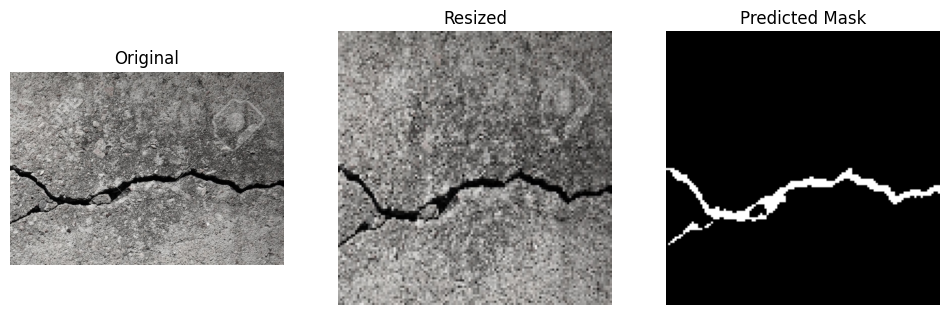

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import glob
from tensorflow.keras.models import load_model

model = load_model("unet_crackforest.keras", compile=False)

IMG_SIZE = 128
IMAGE_DIR = "/content/drive/MyDrive/DeepCrack/test_img"

test_img_path = np.random.choice(glob.glob(IMAGE_DIR + "/*.jpg"))

img = cv2.imread(test_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE)) / 255.0

inp = np.expand_dims(img_resized, 0)
pred = model.predict(inp)[0]
pred_mask = (pred > 0.5).astype(np.uint8)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Original"); plt.imshow(img_rgb); plt.axis("off")
plt.subplot(1,3,2); plt.title("Resized"); plt.imshow(img_resized); plt.axis("off")
plt.subplot(1,3,3); plt.title("Predicted Mask"); plt.imshow(pred_mask.squeeze(), cmap="gray"); plt.axis("off")
plt.show()

Crack Detected!
Avg Width: 5.02 px
Max Width: 14.00 px
Severity : MEDIUM


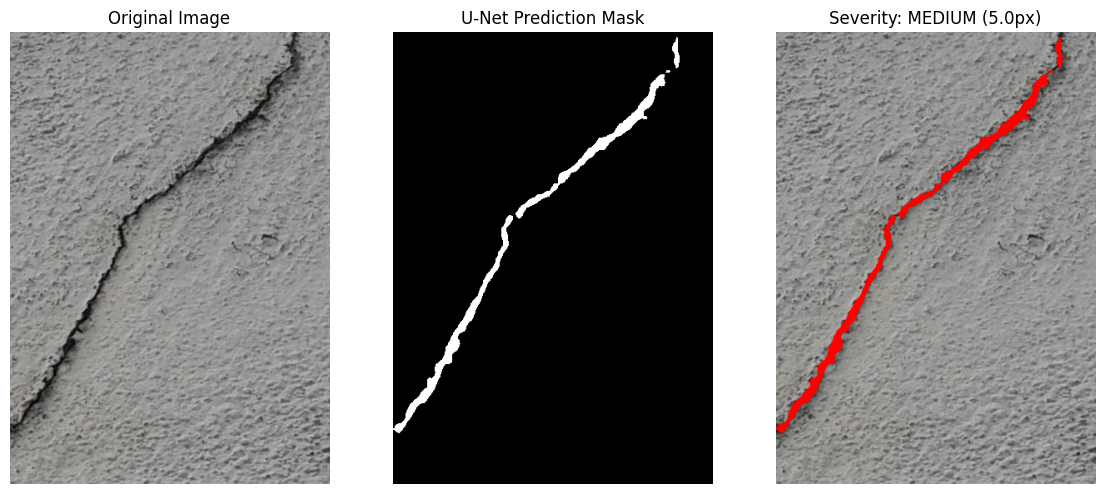

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

model = load_model("unet_crackforest.keras", compile=False)

def crack_width_and_severity_unet(path, model):
    img = cv2.imread(path)
    if img is None:
        print("Image not found")
        return

    original_h, original_w = img.shape[:2]

    img_resized = cv2.resize(img, (128, 128))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    img_normalized = img_rgb / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)

    pred = model.predict(img_input, verbose=0)[0]

    pred_mask = cv2.resize(pred, (original_w, original_h))

    binary_mask = (pred_mask > 0.5).astype(np.uint8) * 255
    dist = cv2.distanceTransform(binary_mask, cv2.DIST_L2, 5)

    widths = dist[binary_mask == 255] * 2

    if len(widths) == 0:
        print("No crack found")
        return

    # Calculate Metrics
    avg_width = np.mean(widths)
    max_width = np.max(widths) # Added max width for better context

    # Severity Logic (Based on your snippet)
    if avg_width < 4:
        severity = "NARROW"
    elif avg_width < 8:
        severity = "MEDIUM"
    else:
        severity = "WIDE"

    print(f"Crack Detected!")
    print(f"Avg Width: {avg_width:.2f} px")
    print(f"Max Width: {max_width:.2f} px")
    print(f"Severity : {severity}")

    # Create red overlay
    output = img.copy()
    output[binary_mask == 255] = [0, 0, 255] # Red overlay on original image

    plt.figure(figsize=(14, 7))

    # Plot 1: Original
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")

    # Plot 2: U-Net Mask
    plt.subplot(1, 3, 2)
    plt.imshow(binary_mask, cmap="gray")
    plt.title("U-Net Prediction Mask")
    plt.axis("off")

    # Plot 3: Overlay with Heatmap info
    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.title(f"Severity: {severity} ({avg_width:.1f}px)")
    plt.axis("off")

    plt.show()

crack_width_and_severity_unet("/content/drive/MyDrive/DeepCrack/test_img/111212-1.jpg", model)